# HW2 — Part 1: Training Quantized Models

**Run this notebook on Lambda inside a GPU Slurm session.**  
See `README.md` sections 1.4–1.7 for setup.

In this notebook you will:
1. Train the provided **W16A8** model (16-bit weights, 8-bit activations) and export to ONNX
2. Train the provided **W2A1** model (2-bit weights, 1-bit activations) and export to ONNX
3. Answer the questions after each model
4. Generate test data for the FPGA board
5. (Open-ended) Design, train, and export your own quantization configuration

When done, exit the GPU session and open **`02_synthesis.ipynb`** in a CPU Slurm session (see `README.md` section 1.8).

## 0. Environment Check

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — start a GPU Slurm session first (see README.md 1.4)"
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"PyTorch:  {torch.__version__}")
import brevitas; print(f"Brevitas: {brevitas.__version__}")

GPU:      NVIDIA GeForce RTX 2080 Ti
PyTorch:  2.5.1+cu121
Brevitas: 0.12.1


In [2]:
import os, sys
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

import brevitas.nn as qnn
from brevitas.export import export_qonnx
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant import Int8ActPerTensorFloat

WORKDIR = os.path.expanduser('~/fpga_hw2')
os.makedirs(WORKDIR, exist_ok=True)
os.chdir(WORKDIR)
print(f"Working directory: {WORKDIR}")

INPUT_SIZE  = 3 * 32 * 32  # 3072
HIDDEN_SIZE = 64
NUM_CLASSES = 10
BATCH_SIZE  = 128
DEVICE      = torch.device('cuda')

/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/brevitas/graph/equalize.py:69: UserWarning: fast_hadamard_transform package not found, using standard pytorch kernels
  warnings.warn("fast_hadamard_transform package not found, using standard pytorch kernels")


Working directory: /home/shahlaandrew/fpga_hw2


## 1. Data Loading

In [3]:
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
full_train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_ds       = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_ds, val_ds = random_split(full_train_ds, [45000, 5000],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256,        shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Files already downloaded and verified
Files already downloaded and verified
Train: 45000 | Val: 5000 | Test: 10000


/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 2. Training Utilities (provided)

In [4]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out = model(images)
            total_loss += criterion(out, labels).item() * labels.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def train_model(model, epochs, lr, ckpt_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'Epoch {epoch:3d}/{epochs}  train={tr_acc:.3f}  val={vl_acc:.3f}')
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), ckpt_path)
    print(f'\nBest val accuracy: {best_acc:.3f}  saved to {ckpt_path}')
    return history

def plot_training(history, title):
    epochs = range(1, len(history['train_acc']) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [a*100 for a in history['train_acc']], label='Train')
    plt.plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title(title)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print('Utilities ready.')

Utilities ready.


## 3. ONNX Export Utility (provided)

**What is ONNX?** ONNX (Open Neural Network Exchange) is an open format for representing machine learning models as a computation graph. When you call `export_qonnx()`, the trained Brevitas model is serialized into a `.onnx` file that captures every operation — quantized linear layers, activation quantizers, BipolarQuant nodes — along with the learned weights and scale factors. This `.onnx` file is the sole input to FINN in `02_synthesis.ipynb`; FINN reads the graph and compiles each layer into dedicated FPGA hardware.

FINN requires `BipolarQuant` scale == exactly 1.0. This cell exports the model and validates that constraint.

In [5]:
import onnx
import numpy as np

def export_and_validate(model, onnx_path, check_bipolar_scale=True):
    model.eval().cpu()
    dummy = torch.randn(1, INPUT_SIZE)
    export_qonnx(model, input_t=dummy, export_path=onnx_path)

    m = onnx.load(onnx_path)
    bipolar_scale_names = {n.input[1] for n in m.graph.node if n.op_type == 'BipolarQuant'}

    for init in m.graph.initializer:
        if init.name not in bipolar_scale_names:
            continue
        val = float(np.frombuffer(init.raw_data, dtype=np.float32)[0]) if init.raw_data else float(init.float_data[0])
        if check_bipolar_scale and abs(val - 1.0) > 1e-4:
            raise RuntimeError(
                f'BipolarQuant scale = {val:.4f}, expected exactly 1.0. '
                'Use SignedBinaryActPerTensorConst, not QuantHardTanh.')
        # Patch to exactly 1.0 (FINN hard requirement)
        init.raw_data = np.ones(1, dtype=np.float32).tobytes()
        init.float_data[:] = []

    onnx.save(m, onnx_path)
    model.to(DEVICE)
    n_bipolar = len(bipolar_scale_names)
    print(f'Exported: {onnx_path}')
    if n_bipolar:
        print(f'  BipolarQuant scale == 1.0 confirmed ({n_bipolar} node(s))')
    else:
        print('  No BipolarQuant nodes (INT8 model)')

print('Export utility ready.')

Export utility ready.


---
## 4. Model A — W16A8 (16-bit weights, 8-bit activations)

### Background

W16A8 increases weight precision to 16 bits while keeping activations at 8 bits:
- **Weights**: 16-bit integers — stored in FPGA BRAM (expect high BRAM utilization)
- **Activations**: 8-bit integers — FINN compiles to MultiThreshold layers

FINN can synthesize W16A8 because activations stay ≤ 8 bits (FINN's hard limit for MultiThreshold). A pure W16A16 model fails synthesis.

In [6]:
class QuantFCNetW16A8(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_q = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc1  = qnn.QuantLinear(INPUT_SIZE,  HIDDEN_SIZE, bias=False, weight_bit_width=16, return_quant_tensor=True)
        self.act1 = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc2  = qnn.QuantLinear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False, weight_bit_width=16, return_quant_tensor=True)
        self.act2 = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc3  = qnn.QuantLinear(HIDDEN_SIZE, NUM_CLASSES, bias=False, weight_bit_width=16, return_quant_tensor=False)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_q(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

model_w16a8 = QuantFCNetW16A8().to(DEVICE)
with torch.no_grad():
    out = model_w16a8(torch.randn(4, INPUT_SIZE, device=DEVICE))
print(f'W16A8 output shape: {out.shape}  (expected [4, 10])')

/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/_tensor.py:1488: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1928.)
  return super().rename(names)


W16A8 output shape: torch.Size([4, 10])  (expected [4, 10])


Epoch   1/15  train=0.357  val=0.378
Epoch   2/15  train=0.386  val=0.390
Epoch   3/15  train=0.398  val=0.402
Epoch   4/15  train=0.406  val=0.401
Epoch   5/15  train=0.413  val=0.407
Epoch   6/15  train=0.419  val=0.414
Epoch   7/15  train=0.427  val=0.401
Epoch   8/15  train=0.440  val=0.418
Epoch   9/15  train=0.447  val=0.427
Epoch  10/15  train=0.456  val=0.424
Epoch  11/15  train=0.461  val=0.434
Epoch  12/15  train=0.470  val=0.433
Epoch  13/15  train=0.474  val=0.440
Epoch  14/15  train=0.479  val=0.437
Epoch  15/15  train=0.481  val=0.438

Best val accuracy: 0.440  saved to finn_model_w16a8.pt


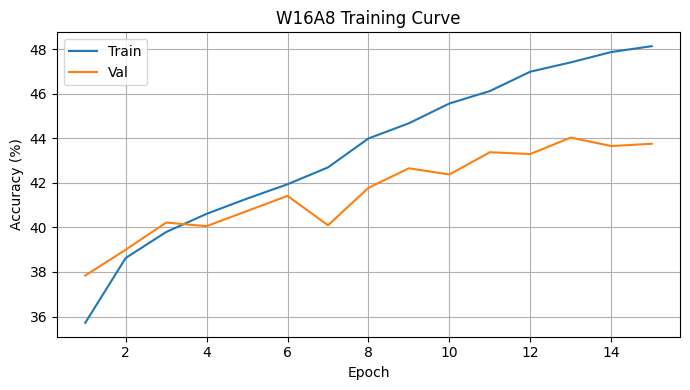

In [7]:
history_w16a8 = train_model(model_w16a8, epochs=15, lr=1e-3, ckpt_path='finn_model_w16a8.pt')
plot_training(history_w16a8, 'W16A8 Training Curve')

In [ ]:
%%bash
nvidia-smi

In [9]:
model_w16a8.load_state_dict(torch.load('finn_model_w16a8.pt', map_location=DEVICE, weights_only=True))
export_and_validate(model_w16a8, 'model_w16a8.onnx', check_bipolar_scale=False)

Exported: model_w16a8.onnx
  No BipolarQuant nodes (INT8 model)


### Questions — W16A8
1. What is Quantization-Aware Training (QAT)? How does the gradient flow through the non-differentiable quantization step during backpropagation?
2. Your W16A8 model uses INT8 activations trained with QAT. A float32 MLP of this architecture on CIFAR-10 typically achieves 55–58% test accuracy. How does your result compare, and what does this tell you about the accuracy cost of INT8 quantization with QAT?

**Your answer:**

1. QAT simulates quantization in the forward pass during training, that way the weights can learn to tolerate quantization errors from the training phase so they dont encounter it for the first time at depoloyment.

   the problem is rounding gives us a "step" function, so its non-diferentiable, the gradient is zero almost everywhere, which would prevent weights from ever updating, QAT solves this by simulating quantization in the forward pass so the model can experience what low-percision feels like, but in the backpropagation it actually just ignores that rounding and trains on the real values so the gradients are unchanged, this approximation lets training converge on weights that work well under quantization.

2. Our model reached 44% accuracy, so our test results are slightly below that 55-58% range, this suggests that INT8 activation quantization with QAT introduces minimal-moderate accuracy loss, since the model had the opportunity to adapt to the constraints during training rather than being quantized post-hoc.

---
## 5. Model B — W2A1 (2-bit weights, 1-bit activations)

### Background

W2A1 is an extremely aggressive quantization:
- **Weights**: ternary `{-1, 0, +1}` stored as 2-bit values
- **Activations**: bipolar `{-1, +1}` — 1 bit per activation

FINN compiles bipolar activations using XNOR+popcount logic in LUTs — no multipliers needed, very low resource usage.

> **Use `SignedBinaryActPerTensorConst`** for all activation quantizers. It has `scaling_impl_type=CONST` which keeps the scale fixed at 1.0 throughout training. Do **not** use `QuantHardTanh` — its scale is learnable and will drift, causing FPGA threshold miscalibration.

In [10]:
class QuantFCNetW2A1(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_q = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc1  = qnn.QuantLinear(INPUT_SIZE,  HIDDEN_SIZE, bias=False, weight_bit_width=2, return_quant_tensor=True)
        self.act1 = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc2  = qnn.QuantLinear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False, weight_bit_width=2, return_quant_tensor=True)
        self.act2 = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc3  = qnn.QuantLinear(HIDDEN_SIZE, NUM_CLASSES, bias=False, weight_bit_width=2, return_quant_tensor=False)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_q(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

model_w2a1 = QuantFCNetW2A1().to(DEVICE)
with torch.no_grad():
    out = model_w2a1(torch.randn(4, INPUT_SIZE, device=DEVICE))
print(f'W2A1 output shape: {out.shape}  (expected [4, 10])')

W2A1 output shape: torch.Size([4, 10])  (expected [4, 10])


/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch   1/15  train=0.301  val=0.336
Epoch   2/15  train=0.345  val=0.349
Epoch   3/15  train=0.357  val=0.353
Epoch   4/15  train=0.371  val=0.364
Epoch   5/15  train=0.380  val=0.361
Epoch   6/15  train=0.388  val=0.359
Epoch   7/15  train=0.396  val=0.368
Epoch   8/15  train=0.407  val=0.367
Epoch   9/15  train=0.417  val=0.368
Epoch  10/15  train=0.425  val=0.367
Epoch  11/15  train=0.439  val=0.385
Epoch  12/15  train=0.450  val=0.375
Epoch  13/15  train=0.460  val=0.374
Epoch  14/15  train=0.467  val=0.378
Epoch  15/15  train=0.475  val=0.375

Best val accuracy: 0.385  saved to finn_model_w2a1.pt


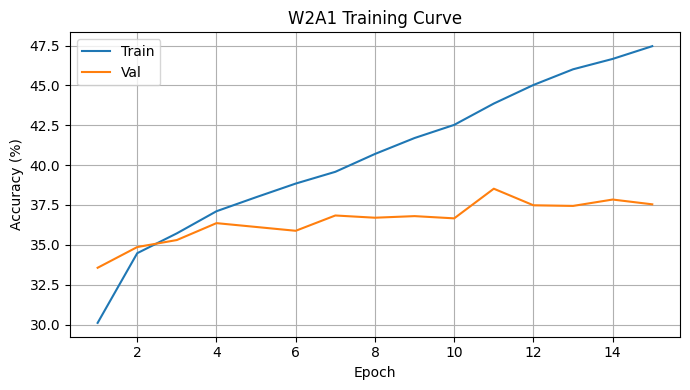

In [11]:
history_w2a1 = train_model(model_w2a1, epochs=15, lr=1e-3, ckpt_path='finn_model_w2a1.pt')
plot_training(history_w2a1, 'W2A1 Training Curve')

In [12]:
model_w2a1.load_state_dict(torch.load('finn_model_w2a1.pt', map_location=DEVICE, weights_only=True))
export_and_validate(model_w2a1, 'model_w2a1.onnx', check_bipolar_scale=True)

Exported: model_w2a1.onnx
  BipolarQuant scale == 1.0 confirmed (1 node(s))


In [13]:
# Confirm ONNX files are ready
for fname in ['model_w2a1.onnx', 'model_w16a8.onnx']:
    path = os.path.join(WORKDIR, fname)
    assert os.path.exists(path), f'Missing {path}'
    print(f'{fname}: {os.path.getsize(path)//1024} KB  ready')
print('\nAll good — exit the GPU session and open 02_synthesis.ipynb')

model_w2a1.onnx: 790 KB  ready
model_w16a8.onnx: 790 KB  ready

All good — exit the GPU session and open 02_synthesis.ipynb


In [14]:
# Summary — paste these into 03_board_inference.ipynb when plotting results
# Models already hold best-val checkpoint weights (loaded above for ONNX export)
criterion = nn.CrossEntropyLoss()
_, sw_acc_w2a1_frac  = evaluate(model_w2a1,  test_loader, criterion)
_, sw_acc_w16a8_frac = evaluate(model_w16a8, test_loader, criterion)
sw_acc_w2a1  = sw_acc_w2a1_frac  * 100
sw_acc_w16a8 = sw_acc_w16a8_frac * 100

print('=' * 54)
print('Paste these into 03_board_inference.ipynb cell-19:')
print('=' * 54)
print(f'sw_acc_w2a1  = {sw_acc_w2a1:.1f}')
print(f'sw_acc_w16a8 = {sw_acc_w16a8:.1f}')

/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Paste these into 03_board_inference.ipynb cell-19:
sw_acc_w2a1  = 38.2
sw_acc_w16a8 = 43.5


In [ ]:
======================================================
Paste these into 03_board_inference.ipynb cell-19:
======================================================
sw_acc_w2a1  = 38.2
sw_acc_w16a8 = 43.5

---
## 6. Prepare Test Data for the Board

CIFAR-10 test data is already loaded. Generate the board-ready files here while the ONNX models are fresh. Copy commands are in `02_synthesis.ipynb` section 4.

In [ ]:
# Collect all test images from test_loader (already downloaded in section 1)
all_imgs, all_labels = [], []
for imgs_batch, lbls_batch in test_loader:
    all_imgs.append(imgs_batch.numpy())
    all_labels.append(lbls_batch.numpy())
imgs_flat  = np.concatenate(all_imgs).reshape(-1, 3072)   # (10000, 3072), CHW float32
test_lbls  = np.concatenate(all_labels)                    # (10000,)

# W2A1: natural sign → bipolar, FINN packing (bit=0 → +1, bit=1 → -1)
bipolar = np.sign(imgs_flat).astype(np.float32)
bipolar[bipolar == 0] = 1.0
N = len(bipolar)
folded  = bipolar.reshape(N, 768, 4)
binary  = ((1 - folded.astype(np.int8)) // 2).astype(np.uint8)
packed_w2a1 = (binary * np.array([1, 2, 4, 8], dtype=np.uint8)).sum(axis=-1, keepdims=True).astype(np.uint8)

# W16A8: INT8 quantized using the learned input scale from the exported ONNX
m_w16a8 = onnx.load(os.path.join(WORKDIR, 'model_w16a8.onnx'))
quant_scales = {}
for node in m_w16a8.graph.node:
    if node.op_type == 'Quant' and len(node.input) >= 2:
        quant_scales[node.output[0]] = node.input[1]
scale_name  = list(quant_scales.values())[0] if quant_scales else None
input_scale = 1.0
for init in m_w16a8.graph.initializer:
    if init.name == scale_name:
        input_scale = float(np.frombuffer(init.raw_data, dtype=np.float32)[0])
        break
print(f'W16A8 input quantizer scale: {input_scale:.6f}')
imgs_int8 = np.clip(np.round(imgs_flat / input_scale), -128, 127).astype(np.int8)

np.save(os.path.join(WORKDIR, 'test_images_w2a1_packed.npy'), packed_w2a1)
np.save(os.path.join(WORKDIR, 'test_images_w16a8.npy'),       imgs_int8)
np.save(os.path.join(WORKDIR, 'test_labels.npy'),             test_lbls)
print(f'Saved W2A1 packed: {packed_w2a1.shape} {packed_w2a1.dtype}')
print(f'Saved W16A8 int8:  {imgs_int8.shape}  {imgs_int8.dtype}')
print(f'Saved labels:      {test_lbls.shape}')

---
## 7. Done — Exit the GPU Session

ONNX files, accuracy values, and test data files are all saved. **Release the GPU now** — synthesis is CPU-only and runs in `02_synthesis.ipynb`.

```
# Then in your terminal:
exit   ← exits the GPU srun session
```

Next: open `02_synthesis.ipynb` in a new CPU Slurm session (see `README.md` section 1.8).